# Testing Model

En este notebook se realizarán pruebas del modelo de clusterización bioinspirado con diferentes funciones de distancia y métodos de selección de características con el objetivo de encontrar la combinación que maximize el rendimiento del algoritmo usando el coeficiente de Silhouette para medir la calidad de la clusterización realizada.

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# Distancia Euclidiana


In [50]:
# Algoritmo bioinspirado en la expansión del reino fungi
class FungiInspiredClustering:
    """
    Algoritmo de clustering bioinspirado en la expansión del micelio del reino fungi.

    El algoritmo simula la expansión caótica local y el reajuste global observado en el crecimiento
    de los hongos para agrupar datos. Utiliza una combinación de búsqueda local con ruido aleatorio
    (expansión caótica) y ajuste global (expansión dirigida) para encontrar grupos de datos de manera eficiente.

    Parámetros
    ----------
    Distance_Function : callable
        Función que calcula la distancia entre dos puntos.
    n_clusters : int, opcional (por defecto=5)
        Número de clusters que se desean formar.
    max_iter : int, opcional (por defecto=100)
        Número máximo de iteraciones que ejecutará el algoritmo.
    local_radius : float, opcional (por defecto=1.0)
        Radio de expansión local que simula ruido aleatorio en la asignación de clusters.
    global_radius : float, opcional (por defecto=5.0)
        Radio de ajuste global para el reajuste de los centroides.
    tolerance : float, opcional (por defecto=1e-4)
        Criterio de convergencia. Si los centroides cambian menos que este valor, el algoritmo se detendrá.

    Atributos
    ---------
    centroids : ndarray de forma (n_clusters, n_features)
        Posiciones finales de los centroides después del ajuste.
    labels : ndarray de forma (n_samples,)
        Etiquetas de cluster para cada punto de los datos.
    """

    def __init__(self,Distance_Function, n_clusters=5, max_iter=100, local_radius=1.0, global_radius=5.0, tolerance=1e-4):
        """
        Inicializa el algoritmo de clustering inspirado en el reino fungi.

        Parámetros
        ----------
        Distance_Function : callable
            Función que calcula la distancia entre dos puntos.
        n_clusters : int, opcional (por defecto=5)
            Número de clusters que se desean formar.
        max_iter : int, opcional (por defecto=100)
            Número máximo de iteraciones que ejecutará el algoritmo.
        local_radius : float, opcional (por defecto=1.0)
            Radio de expansión local que simula ruido aleatorio.
        global_radius : float, opcional (por defecto=5.0)
            Radio de ajuste global para el reajuste de los centroides.
        tolerance : float, opcional (por defecto=1e-4)
            Criterio de convergencia.
        """
        self.Distance_Function = Distance_Function
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.local_radius = local_radius
        self.global_radius = global_radius
        self.tolerance = tolerance

    def fit(self, X):
        """
        Ajusta el modelo FungiInspiredClustering a los datos.

        Parámetros
        ----------
        X : ndarray de forma (n_samples, n_features)
            Conjunto de datos a agrupar.

        Devuelve
        --------
        None
        """
        # Inicializar las "esporas" (centroides iniciales) aleatoriamente
        np.random.seed(42)  # Para reproducibilidad
        random_indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.centroids = X[random_indices]

        for i in range(self.max_iter):
            # Fase 1: Expansión local (caótica)
            self.labels = self.assign_local_clusters(X)

            # Fase 2: Reajuste global (dirigida)
            old_centroids = self.centroids.copy()
            self.centroids = self.calculate_new_centroids(X)

            # Verificar convergencia
            if self.has_converged(old_centroids):
                print(f"Convergencia alcanzada en la iteración {i+1}")
                break

    def assign_local_clusters(self, X):
        """
        Asigna cada punto de datos al cluster más cercano utilizando la expansión local con ruido.

        Parámetros
        ----------
        X : ndarray de forma (n_samples, n_features)
            Conjunto de datos a agrupar.

        Devuelve
        --------
        labels : ndarray de forma (n_samples,)
            Etiquetas de cluster para cada punto de datos.
        """
        labels = []
        for point in X:
            distances = [self.Distance_Function(point, centroid) for centroid in self.centroids]

            # Expansión local caótica: Agregar ruido a la distancia para simular crecimiento aleatorio
            noisy_distances = [dist + np.random.uniform(-self.local_radius, self.local_radius) for dist in distances]
            labels.append(np.argmin(noisy_distances))
        return np.array(labels)

    def calculate_new_centroids(self, X):
        """
        Recalcula los centroides promediando los puntos en cada cluster y agregando ajuste global.

        Parámetros
        ----------
        X : ndarray de forma (n_samples, n_features)
            Conjunto de datos para el cálculo de nuevos centroides.

        Devuelve
        --------
        centroids : ndarray de forma (n_clusters, n_features)
            Nuevas posiciones de los centroides.
        """
        centroids = []
        for i in range(self.n_clusters):
            points_in_cluster = X[self.labels == i]
            if len(points_in_cluster) > 0:
                # Expansión global: Ajuste de los centroides hacia áreas ricas en puntos
                new_centroid = points_in_cluster.mean(axis=0) + np.random.uniform(-self.global_radius, self.global_radius, size=points_in_cluster.shape[1])
            else:
                # Si el clúster está vacío, reasignar un centroide aleatorio
                new_centroid = X[np.random.choice(X.shape[0])]
            centroids.append(new_centroid)
        return np.array(centroids)

    def has_converged(self, old_centroids):
        """
        Verifica si los centroides han convergido basado en el umbral de tolerancia.

        Parámetros
        ----------
        old_centroids : ndarray de forma (n_clusters, n_features)
            Posiciones anteriores de los centroides.

        Devuelve
        --------
        bool
            True si los centroides han cambiado menos que el valor de tolerancia, de lo contrario False.
        """
        distances = [self.Distance_Function(old, new) for old, new in zip(old_centroids, self.centroids)]
        return np.max(distances) < self.tolerance


In [51]:
# Cargar el dataset
file_path = '../src/Pruebas/CleanDataset.csv'
df = pd.read_csv(file_path)

Coeficiente de Silhouette: 0.38244186282525283

Centroides finales:
[[ 3.90038979e+03  2.23197045e+00  2.77432875e+03  1.78003085e+03
   9.96751020e+02  8.24255128e+02 -1.20870798e+00 -7.63986477e-02
  -2.02821391e-01 -1.10116011e+00  2.82575994e+00  3.59052508e+01
   1.30853993e+04  3.17467255e+03 -1.41632980e+00  1.24851520e+01]
 [ 5.13395841e+03  2.17370060e+00  5.80002234e+02  3.26697004e+02
   2.54194151e+02  5.47738059e+03 -1.19017542e+00 -1.10952758e+00
   1.01502437e+00  9.97688575e-01  1.46807352e+01  8.41395981e+00
   8.15992968e+03  4.15378770e+03  2.30537765e-01  1.33877380e+01]
 [ 7.93818000e+02  1.72992869e+00  4.72600045e+02  2.23311259e+02
   2.48453074e+02  4.79573981e+02 -1.46862221e+00 -1.22538306e+00
   1.86737292e+00 -1.42242917e+00  2.45357843e+00  1.06730850e+01
   2.12644216e+03  8.51577579e+02  5.51772267e-02  1.25684718e+01]
 [ 1.54516332e+03  7.03554556e-01  1.42108638e+03  8.63624741e+02
   5.60911827e+02  6.03169709e+02 -4.36023351e-01  1.13990533e-01
   7.

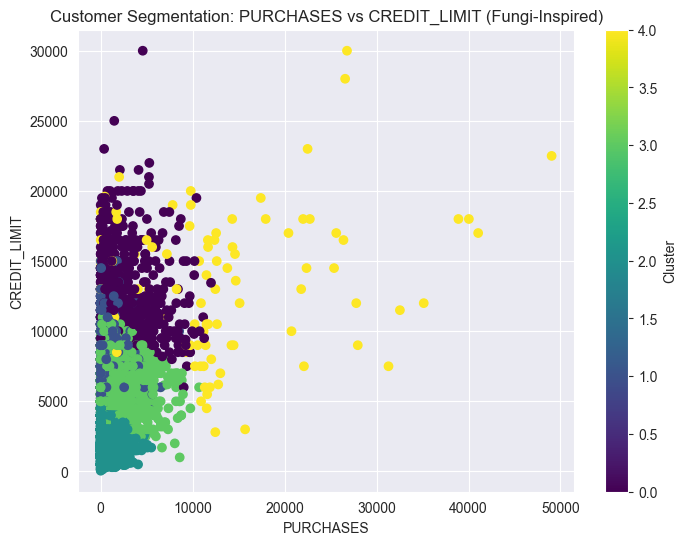

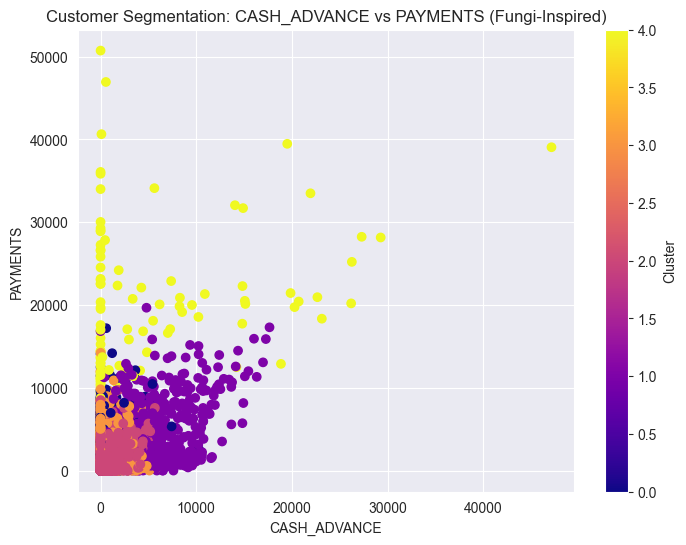

In [52]:
# Función para calcular la distancia euclidiana entre dos puntos
def euclidean_distance(point1, point2):
    """
    Calcula la distancia euclidiana entre dos puntos.

    La distancia euclidiana es la longitud del segmento de línea recta entre dos puntos en un espacio euclidiano.

    Parámetros
    ----------
    point1 : ndarray
        El primer punto como un array NumPy.
    point2 : ndarray
        El segundo punto como un array NumPy.

    Devuelve
    --------
    float
        La distancia euclidiana entre point1 y point2.
    """
    return np.sqrt(np.sum((point1 - point2) ** 2))


# Aplicar nuestro algoritmo FungiInspiredClustering
n_clusters = 5
fungi_clustering = FungiInspiredClustering(
    euclidean_distance, n_clusters=n_clusters, max_iter=100, local_radius=0.5, global_radius=2.0
)
fungi_clustering.fit(df.to_numpy())

# Asignar las etiquetas de clúster al dataframe
df['Cluster'] = fungi_clustering.labels

# Métricas de rendimiento
silhouette_avg = silhouette_score(df.to_numpy(), df['Cluster'])
print(f"Coeficiente de Silhouette: {silhouette_avg}")

# Imprimir datos de centroides y asignaciones
print(f"\nCentroides finales:\n{fungi_clustering.centroids}\n")

# Tamaño de cada clúster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Tamaño de cada clúster:\n{cluster_sizes}\n")

# Visualización: Graficar PURCHASES vs CREDIT_LIMIT con los clústeres
plt.figure(figsize=(8,6))
plt.scatter(df['PURCHASES'], df['CREDIT_LIMIT'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title("Segmentación de clientes: PURCHASES vs CREDIT_LIMIT (Inspirado en hongos)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT_LIMIT")
plt.colorbar(label="Cluster")
plt.show()

# Visualización: CASH_ADVANCE vs PAYMENTS
plt.figure(figsize=(8,6))
plt.scatter(df['CASH_ADVANCE'], df['PAYMENTS'], c=df['Cluster'], cmap='plasma', marker='o')
plt.title("Segmentación de clientes: CASH_ADVANCE vs PAYMENTS (Inspirado en hongos)")
plt.xlabel("CASH_ADVANCE")
plt.ylabel("PAYMENTS")
plt.colorbar(label="Cluster")
plt.show()

Coeficiente de Silhouette: 0.4743114981179011

Centroides finales:
[[ 5.27304350e+03  2.20513008e+00  1.40453785e+03  6.74713449e+02
   7.32462387e+02  1.08730057e+04 -1.53726715e+00 -3.46485932e-01
  -4.21714770e-01 -7.09788443e-01  2.13116554e+01  2.07949450e+01
   1.06805252e+04  1.45570158e+04 -1.45979222e+00  1.22921403e+01]
 [ 4.81916034e+03  2.17998678e+00  6.65400639e+02  4.06003985e+02
   2.60246368e+02  3.17937713e+03 -1.11371448e+00 -1.05452734e+00
   1.06329266e+00  8.82566845e-01  9.81164345e+00  1.03372245e+01
   8.96642971e+03  2.53440684e+03  2.15265013e-01  1.35300453e+01]
 [ 8.65303976e+02  1.73606156e+00  6.07227321e+02  3.05910642e+02
   3.00456261e+02  4.87493196e+02 -1.43433232e+00 -1.18443092e+00
   1.88115656e+00 -1.43063610e+00  2.30292258e+00  1.25450800e+01
   3.26552381e+03  1.01734882e+03  7.62534860e-02  1.26695270e+01]
 [ 2.60457774e+03  7.69271073e-01  5.54172201e+03  3.67344639e+03
   1.87245828e+03  4.37578708e+02 -1.14973385e-01  4.89467521e-01
   1.0

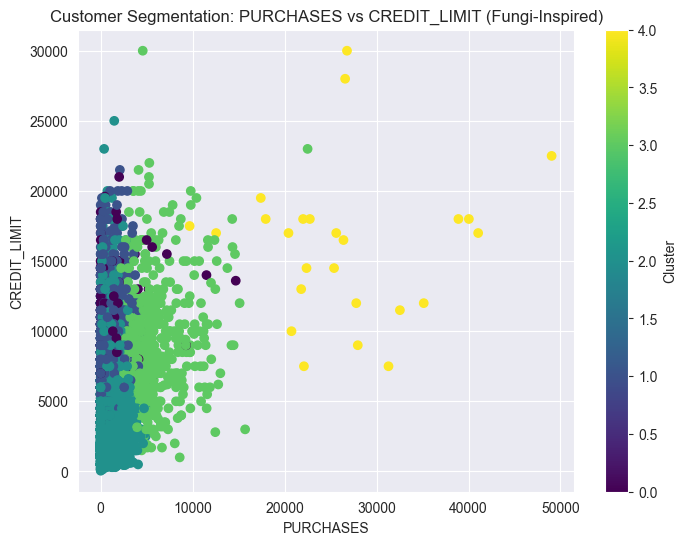

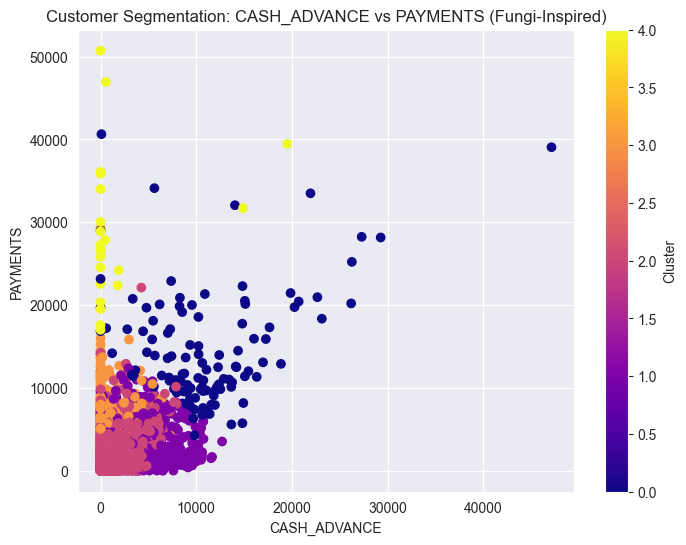

In [53]:
# Función para la distancia Manhattan
def manhattan_distance(point1, point2):
    """
    Calcula la distancia Manhattan entre dos puntos.

    La distancia Manhattan (también conocida como distancia L1) es la suma de las distancias absolutas
    a lo largo de cada dimensión entre dos puntos.

    Parámetros
    ----------
    point1 : ndarray
        El primer punto como un array NumPy.
    point2 : ndarray
        El segundo punto como un array NumPy.

    Devuelve
    --------
    float
        La distancia Manhattan entre point1 y point2.
    """
    return np.sum(np.abs(point1 - point2))

# Cargar el archivo CSV en un dataframe de pandas
df = pd.read_csv(file_path)

# Aplicar nuestro algoritmo FungiInspiredClustering
n_clusters = 5
fungi_clustering = FungiInspiredClustering(
    manhattan_distance, n_clusters=n_clusters, max_iter=100, local_radius=0.5, global_radius=2.0
)
fungi_clustering.fit(df.to_numpy())

# Asignar las etiquetas de clúster al dataframe
df['Cluster'] = fungi_clustering.labels

# Métricas de rendimiento: Coeficiente de Silhouette
silhouette_avg = silhouette_score(df.to_numpy(), df['Cluster'])
print(f"Coeficiente de Silhouette: {silhouette_avg}")

# Imprimir datos de centroides y asignaciones
print(f"\nCentroides finales:\n{fungi_clustering.centroids}\n")

# Tamaño de cada clúster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Tamaño de cada clúster:\n{cluster_sizes}\n")

# Visualización: Graficar PURCHASES vs CREDIT_LIMIT con los clústeres
plt.figure(figsize=(8,6))
plt.scatter(df['PURCHASES'], df['CREDIT_LIMIT'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title("Segmentación de clientes: PURCHASES vs CREDIT_LIMIT (Inspirado en hongos)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT_LIMIT")
plt.colorbar(label="Cluster")
plt.show()

# Visualización: CASH_ADVANCE vs PAYMENTS
plt.figure(figsize=(8,6))
plt.scatter(df['CASH_ADVANCE'], df['PAYMENTS'], c=df['Cluster'], cmap='plasma', marker='o')
plt.title("Segmentación de clientes: CASH_ADVANCE vs PAYMENTS (Inspirado en hongos)")
plt.xlabel("CASH_ADVANCE")
plt.ylabel("PAYMENTS")
plt.colorbar(label="Cluster")
plt.show()

Coeficiente de Silhouette: 0.31709864739114957

Centroides finales:
[[ 2.03869994e+03  2.21999107e+00  2.49576174e+03  1.65096939e+03
   8.47979617e+02  4.04232628e+02 -1.22609712e+00 -8.55114625e-02
  -2.34779531e-01 -1.14684698e+00  1.84559207e+00  3.18282352e+01
   1.08324645e+04  2.62589733e+03 -1.36340431e+00  1.24450168e+01]
 [ 5.79951297e+03  2.18054276e+00  7.55054144e+02  4.18158662e+02
   3.37774125e+02  4.91138594e+03 -1.14791693e+00 -1.08399401e+00
   1.05750107e+00  9.72589374e-01  1.34222140e+01  1.15451743e+01
   8.95255914e+03  3.97816625e+03  2.21779911e-01  1.34586910e+01]
 [ 7.42452539e+02  1.73586981e+00  4.34595238e+02  1.97981601e+02
   2.35719449e+02  3.95469759e+02 -1.47052449e+00 -1.23244257e+00
   1.86693433e+00 -1.42760191e+00  2.24684869e+00  1.02326398e+01
   1.82313227e+03  7.47392550e+02  5.14551890e-02  1.25189012e+01]
 [ 1.39109661e+03  6.74987684e-01  1.06362212e+03  6.15415805e+02
   4.51542858e+02  7.97673557e+02 -4.91419717e-01  4.63662682e-02
   6.

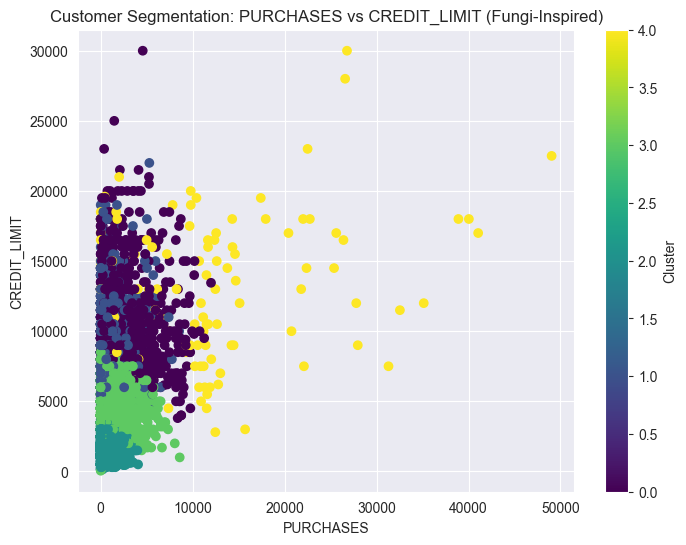

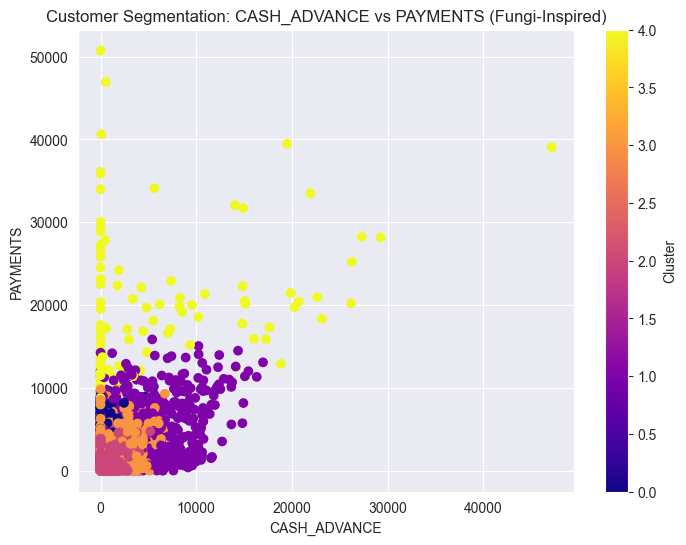

In [54]:
def minkowski_distance(point1, point2, p=3):
    """
    Calcula la distancia de Minkowski entre dos puntos.

    La distancia de Minkowski es una generalización de las distancias Euclidiana y Manhattan.
    Dependiendo del valor de p, puede representar diferentes métricas de distancia:
    - p = 1: Distancia Manhattan
    - p = 2: Distancia Euclidiana
    - p > 2: Otras variantes de la distancia

    Parámetros
    ----------
    point1 : ndarray
        El primer punto como un array NumPy.
    point2 : ndarray
        El segundo punto como un array NumPy.
    p : int, opcional (por defecto=3)
        El parámetro de orden p que define la métrica de Minkowski. p=3 es el valor por defecto.

    Devuelve
    --------
    float
        La distancia de Minkowski entre point1 y point2.
    """
    return np.sum(np.abs(point1 - point2) ** p) ** (1 / p)

# Cargar el archivo CSV en un dataframe de pandas
df = pd.read_csv(file_path)

# Aplicar nuestro algoritmo FungiInspiredClustering
n_clusters = 5
fungi_clustering = FungiInspiredClustering(
    minkowski_distance, n_clusters=n_clusters, max_iter=100, local_radius=0.5, global_radius=2.0
)
fungi_clustering.fit(df.to_numpy())

# Asignar las etiquetas de clúster al dataframe
df['Cluster'] = fungi_clustering.labels

# Métricas de rendimiento: Coeficiente de Silhouette
silhouette_avg = silhouette_score(df.to_numpy(), df['Cluster'])
print(f"Coeficiente de Silhouette: {silhouette_avg}")

# Imprimir datos de centroides y asignaciones
print(f"\nCentroides finales:\n{fungi_clustering.centroids}\n")

# Tamaño de cada clúster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Tamaño de cada clúster:\n{cluster_sizes}\n")

# Visualización: Graficar PURCHASES vs CREDIT_LIMIT con los clústeres
plt.figure(figsize=(8,6))
plt.scatter(df['PURCHASES'], df['CREDIT_LIMIT'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title("Segmentación de clientes: PURCHASES vs CREDIT_LIMIT (Inspirado en hongos)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT_LIMIT")
plt.colorbar(label="Cluster")
plt.show()

# Visualización: CASH_ADVANCE vs PAYMENTS
plt.figure(figsize=(8,6))
plt.scatter(df['CASH_ADVANCE'], df['PAYMENTS'], c=df['Cluster'], cmap='plasma', marker='o')
plt.title("Segmentación de clientes: CASH_ADVANCE vs PAYMENTS (Inspirado en hongos)")
plt.xlabel("CASH_ADVANCE")
plt.ylabel("PAYMENTS")
plt.colorbar(label="Cluster")
plt.show()

# Eliminando características según la matriz de correlación

In [55]:
df = pd.read_csv(file_path)
df= df.drop(columns=['ONEOFF_PURCHASES','PURCHASES_INSTALLMENTS_FREQUENCY','CASH_ADVANCE_TRX','INSTALLMENTS_PURCHASES','CASH_ADVANCE','BALANCE_FREQUENCY'])

Coeficiente de Silhouette: 0.4261261714408456

Centroides finales:
[[ 5.22305403e+03  1.63796722e+03 -7.73974335e-01  1.77162318e+00
   1.91854274e+00  2.11845472e+01  1.24039191e+04  2.55010802e+03
  -6.81752038e-01  1.00908553e+01]
 [ 1.87297524e+03  9.90662243e+02  8.42735548e-01  4.57973016e-01
   3.14653006e-02  1.70453836e+01  6.51557957e+03  1.48502341e+03
   1.21634975e+00  1.27840516e+01]
 [ 7.80830885e+02  5.04073604e+02  2.03392838e+00 -1.19625854e+00
  -5.25970214e-02  1.12971075e+01  2.11934920e+03  8.90724488e+02
   4.95595695e-01  9.89200100e+00]
 [ 2.71735006e+03  3.79304754e+03  1.54967699e+00  1.56515966e-01
   6.37164534e-01  4.37323236e+01  7.43833910e+03  8.09822642e+03
   1.56577280e+00  1.34292876e+01]
 [ 5.83897516e+03  1.54060408e+04  2.17095175e+00  3.89219430e-01
  -7.43875244e-01  9.44040799e+01  1.55942872e+04  2.43854260e+04
  -5.64900568e-01  1.00456050e+01]]

Tamaño de cada clúster:
Cluster
0     705
1    2406
2    5279
3     504
4      56
Name: count, d

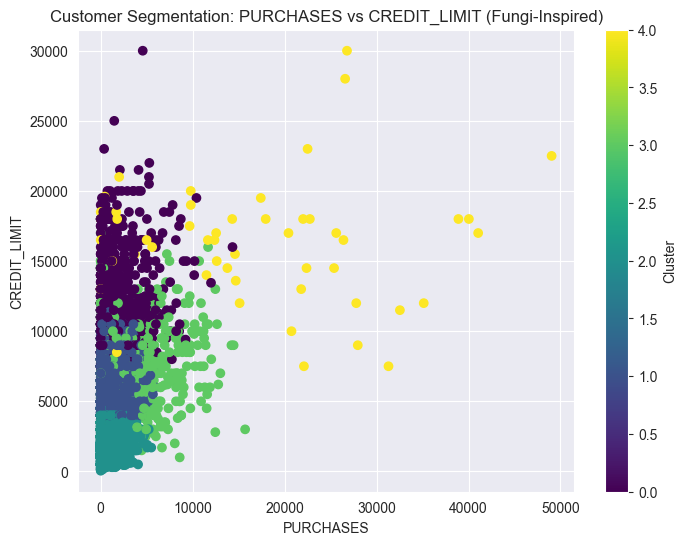

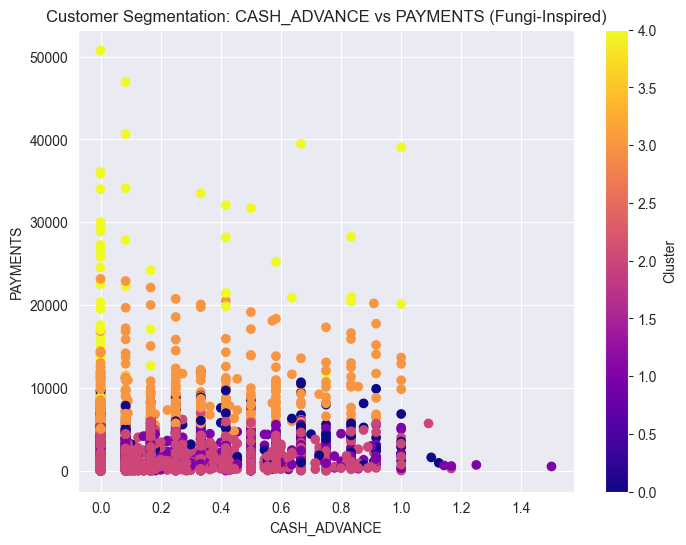

In [56]:
# Función para calcular la distancia euclidiana entre dos puntos
def euclidean_distance(point1, point2):
    """
    Calcula la distancia euclidiana entre dos puntos.

    La distancia euclidiana es la longitud del segmento de línea recta entre dos puntos en un espacio euclidiano.

    Parámetros
    ----------
    point1 : ndarray
        El primer punto como un array NumPy.
    point2 : ndarray
        El segundo punto como un array NumPy.

    Devuelve
    --------
    float
        La distancia euclidiana entre point1 y point2.
    """
    return np.sqrt(np.sum((point1 - point2) ** 2))

# Cargar el archivo CSV en un dataframe de pandas
df = pd.read_csv(file_path)

# Aplicar nuestro algoritmo FungiInspiredClustering
n_clusters = 5
fungi_clustering = FungiInspiredClustering(
    euclidean_distance, n_clusters=n_clusters, max_iter=100, local_radius=0.5, global_radius=2.0
)
fungi_clustering.fit(df.to_numpy())

# Asignar las etiquetas de clúster al dataframe
df['Cluster'] = fungi_clustering.labels

# Métricas de rendimiento: Coeficiente de Silhouette
silhouette_avg = silhouette_score(df.to_numpy(), df['Cluster'])
print(f"Coeficiente de Silhouette: {silhouette_avg}")

# Imprimir datos de centroides y asignaciones
print(f"\nCentroides finales:\n{fungi_clustering.centroids}\n")

# Tamaño de cada clúster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Tamaño de cada clúster:\n{cluster_sizes}\n")

# Visualización: Graficar PURCHASES vs CREDIT_LIMIT con los clústeres
plt.figure(figsize=(8,6))
plt.scatter(df['PURCHASES'], df['CREDIT_LIMIT'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title("Segmentación de clientes: PURCHASES vs CREDIT_LIMIT (Inspirado en hongos)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT_LIMIT")
plt.colorbar(label="Cluster")
plt.show()

# Visualización: CASH_ADVANCE_FREQUENCY vs PAYMENTS
plt.figure(figsize=(8,6))
plt.scatter(df['CASH_ADVANCE_FREQUENCY'], df['PAYMENTS'], c=df['Cluster'], cmap='plasma', marker='o')
plt.title("Segmentación de clientes: CASH_ADVANCE_FREQUENCY vs PAYMENTS (Inspirado en hongos)")
plt.xlabel("CASH_ADVANCE_FREQUENCY")
plt.ylabel("PAYMENTS")
plt.colorbar(label="Cluster")
plt.show()


In [57]:
df=df.drop(columns=['Cluster'])

Coeficiente de Silhouette: 0.4540731153497966

Centroides finales:
[[ 7.01893070e+03  2.06827728e+03 -7.59977268e-01  1.77272385e+00
   1.97415128e+00  2.66586857e+01  1.30578188e+04  4.31992843e+03
  -7.17981836e-01  1.01262963e+01]
 [ 2.23732207e+03  4.28810525e+03  1.04724165e+00  7.00329654e-01
   5.49324911e-02  5.18594775e+01  7.62716591e+03  7.74986044e+03
   1.34143559e+00  1.29652635e+01]
 [ 8.08940767e+02  5.33087540e+02  2.03869397e+00 -1.18751715e+00
  -5.32953379e-02  1.16431843e+01  2.39729579e+03  9.52833477e+02
   5.01909028e-01  9.92608299e+00]
 [ 2.33231935e+03  9.95213699e+02  1.41257579e+00 -2.84038403e-03
   5.92183364e-01  1.43280154e+01  7.64964466e+03  1.58892329e+03
   1.45753055e+00  1.32876429e+01]
 [ 5.73742063e+03  2.02874786e+04  2.25295516e+00  5.01961593e-01
  -8.08123510e-01  1.12177889e+02  1.61578403e+04  2.57366423e+04
  -5.04218423e-01  1.00478944e+01]]

Tamaño de cada clúster:
Cluster
0     426
1     476
2    5875
3    2134
4      39
Name: count, d

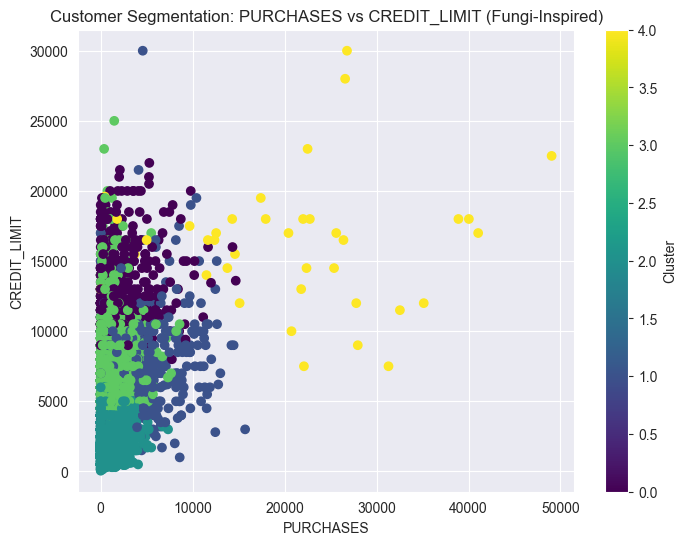

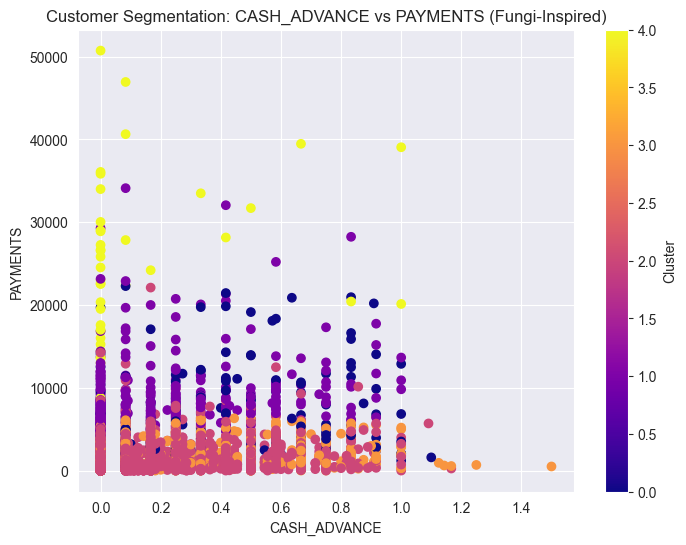

In [58]:
# Aplicar nuestro algoritmo FungiInspiredClustering
n_clusters = 5
fungi_clustering = FungiInspiredClustering(
    manhattan_distance, n_clusters=n_clusters, max_iter=100, local_radius=0.5, global_radius=2.0
)
fungi_clustering.fit(df.to_numpy())

# Asignar las etiquetas de clúster al dataframe
df['Cluster'] = fungi_clustering.labels

# Métricas de rendimiento: Coeficiente de Silhouette
silhouette_avg = silhouette_score(df.to_numpy(), df['Cluster'])
print(f"Coeficiente de Silhouette: {silhouette_avg}")

# Imprimir datos de centroides y asignaciones
print(f"\nCentroides finales:\n{fungi_clustering.centroids}\n")

# Tamaño de cada clúster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Tamaño de cada clúster:\n{cluster_sizes}\n")

# Visualización: Graficar PURCHASES vs CREDIT_LIMIT con los clústeres
plt.figure(figsize=(8,6))
plt.scatter(df['PURCHASES'], df['CREDIT_LIMIT'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title("Segmentación de clientes: PURCHASES vs CREDIT_LIMIT (Inspirado en hongos)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT_LIMIT")
plt.colorbar(label="Cluster")
plt.show()

# Visualización: CASH_ADVANCE_FREQUENCY vs PAYMENTS
plt.figure(figsize=(8,6))
plt.scatter(df['CASH_ADVANCE_FREQUENCY'], df['PAYMENTS'], c=df['Cluster'], cmap='plasma', marker='o')
plt.title("Segmentación de clientes: CASH_ADVANCE_FREQUENCY vs PAYMENTS (Inspirado en hongos)")
plt.xlabel("CASH_ADVANCE_FREQUENCY")
plt.ylabel("PAYMENTS")
plt.colorbar(label="Cluster")
plt.show()


In [59]:
df=df.drop(columns=['Cluster'])

Coeficiente de Silhouette: 0.41781756367479567

Centroides finales:
[[ 5.07942398e+03  1.55578850e+03 -7.83252359e-01  1.76292555e+00
   1.91295798e+00  2.03233474e+01  1.21029344e+04  2.30123569e+03
  -6.85313255e-01  1.00781213e+01]
 [ 1.75527953e+03  1.10487950e+03  8.56803356e-01  4.67399325e-01
   2.56129642e-02  1.85024295e+01  6.29706307e+03  1.63042301e+03
   1.22973754e+00  1.28003075e+01]
 [ 7.84121169e+02  4.92897369e+02  2.03251174e+00 -1.19840848e+00
  -5.25372797e-02  1.11156413e+01  2.07109709e+03  8.60552311e+02
   4.92622894e-01  9.88096307e+00]
 [ 3.20480548e+03  3.74723362e+03  1.50472526e+00  1.24191331e-01
   6.73655716e-01  4.20352745e+01  8.36721439e+03  9.12446411e+03
   1.54565108e+00  1.34096037e+01]
 [ 5.41201844e+03  1.95403686e+04  2.18136270e+00  4.52512634e-01
  -7.91423106e-01  1.05669117e+02  1.52409038e+04  2.76333572e+04
  -5.12400093e-01  1.00465448e+01]]

Tamaño de cada clúster:
Cluster
0     754
1    2549
2    5155
3     454
4      38
Name: count, 

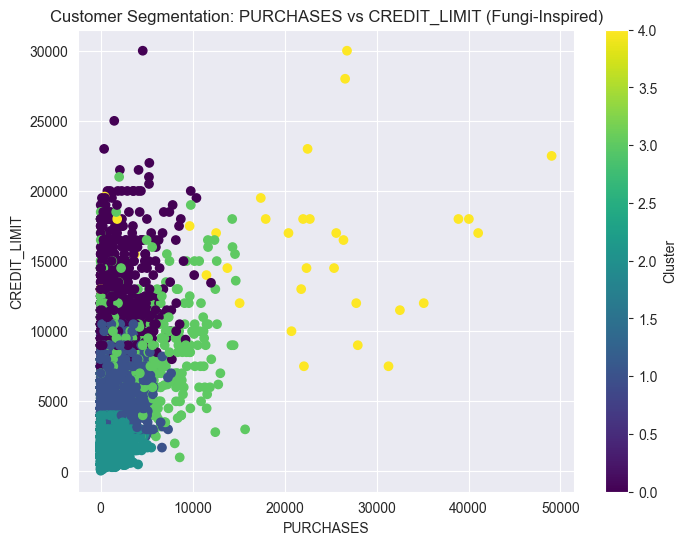

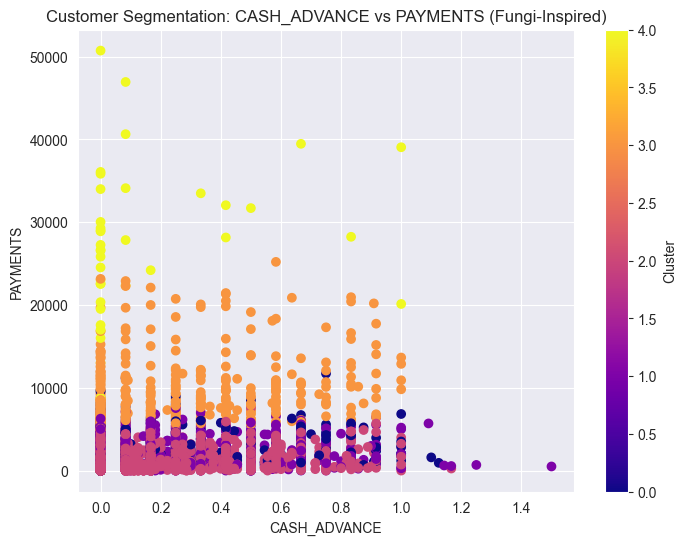

In [60]:
n_clusters = 5
fungi_clustering = FungiInspiredClustering(minkowski_distance,n_clusters=n_clusters, max_iter=100, local_radius=0.5, global_radius=2.0)
fungi_clustering.fit(df.to_numpy())

# Asignar las etiquetas de clúster al dataframe
df['Cluster'] = fungi_clustering.labels

# Métricas de rendimiento
silhouette_avg = silhouette_score(df.to_numpy(), df['Cluster'])
print(f"Coeficiente de Silhouette: {silhouette_avg}")

# Imprimir datos de centroides y asignaciones
print(f"\nCentroides finales:\n{fungi_clustering.centroids}\n")

# Tamaño de cada clúster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Tamaño de cada clúster:\n{cluster_sizes}\n")

# Visualización: Graficar PURCHASES vs CREDIT_LIMIT con los clústeres
plt.figure(figsize=(8,6))
plt.scatter(df['PURCHASES'], df['CREDIT_LIMIT'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title("Customer Segmentation: PURCHASES vs CREDIT_LIMIT (Fungi-Inspired)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT_LIMIT")
plt.colorbar(label="Cluster")
plt.show()

# Visualización: CASH_ADVANCE vs PAYMENTS
plt.figure(figsize=(8,6))
plt.scatter(df['CASH_ADVANCE_FREQUENCY'], df['PAYMENTS'], c=df['Cluster'], cmap='plasma', marker='o')
plt.title("Customer Segmentation: CASH_ADVANCE vs PAYMENTS (Fungi-Inspired)")
plt.xlabel("CASH_ADVANCE")
plt.ylabel("PAYMENTS")
plt.colorbar(label="Cluster")
plt.show()

# Selección de Características Tomando En Cuenta Matriz de Correlación y la PCA

In [61]:
df = pd.read_csv(file_path)
df= df.drop(columns=['ONEOFF_PURCHASES_FREQUENCY','PURCHASES_INSTALLMENTS_FREQUENCY','CASH_ADVANCE_TRX','TENURE','CASH_ADVANCE','BALANCE_FREQUENCY'])

Coeficiente de Silhouette: 0.4070963484417476

Centroides finales:
[[ 5.07150194e+03  1.45641020e+03  9.09579291e+02  5.47213518e+02
   2.20514389e+00 -8.59110860e-01  2.10313583e+01  1.21037488e+04
   2.45659511e+03 -1.57304225e+00]
 [ 1.85552278e+03  1.14603676e+03  6.78514907e+02  4.67520804e+02
   4.29716072e-01  1.47884111e+00  1.65106774e+01  6.42702595e+03
   1.83341158e+03  1.25054691e+00]
 [ 7.84494644e+02  4.84974962e+02  2.34498747e+02  2.52243833e+02
   2.83117362e-01  1.91115067e+00  1.09735427e+01  2.13175992e+03
   8.73114371e+02 -1.32745821e+00]
 [ 3.47739732e+03  4.94393814e+03  3.21679267e+03  1.72916053e+03
   1.12200636e+00 -1.18818033e+00  5.40733019e+01  9.17692000e+03
   1.04973175e+04  1.85016543e+00]
 [ 5.40585935e+03  2.72770626e+04  2.18784931e+04  5.39905852e+03
  -3.37111193e-02  5.70250476e-01  1.29388424e+02  1.60826798e+04
   2.79246957e+04 -1.38961779e+00]]

Tamaño de cada clúster:
Cluster
0     749
1    2521
2    5298
3     358
4      24
Name: count, d

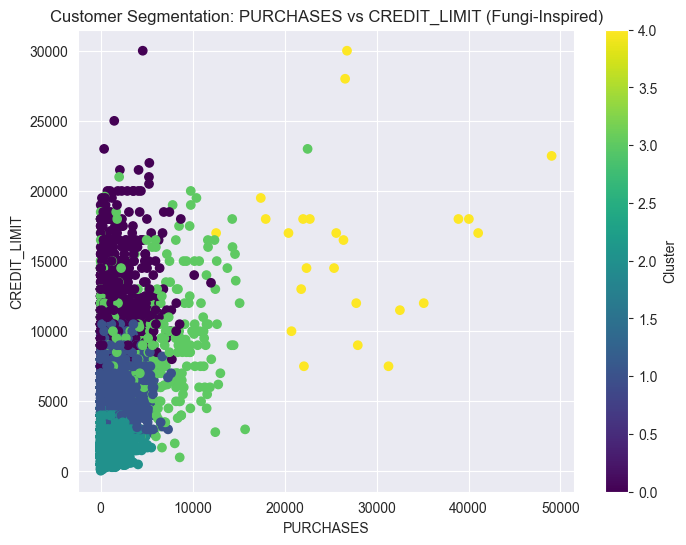

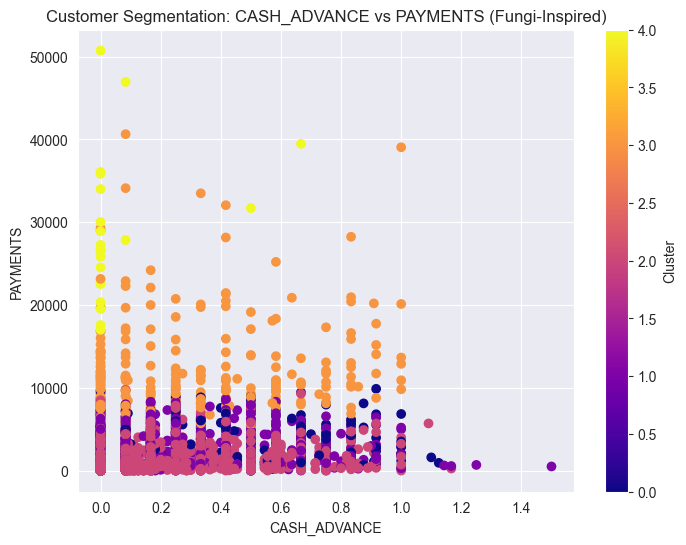

In [62]:
# Aplicar nuestro algoritmo FungiInspiredClustering
n_clusters = 5
fungi_clustering = FungiInspiredClustering(euclidean_distance,n_clusters=n_clusters, max_iter=100, local_radius=0.5, global_radius=2.0)
fungi_clustering.fit(df.to_numpy())

# Asignar las etiquetas de clúster al dataframe
df['Cluster'] = fungi_clustering.labels

# Métricas de rendimiento
silhouette_avg = silhouette_score(df.to_numpy(), df['Cluster'])
print(f"Coeficiente de Silhouette: {silhouette_avg}")

# Imprimir datos de centroides y asignaciones
print(f"\nCentroides finales:\n{fungi_clustering.centroids}\n")

# Tamaño de cada clúster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Tamaño de cada clúster:\n{cluster_sizes}\n")

# Visualización: Graficar PURCHASES vs CREDIT_LIMIT con los clústeres
plt.figure(figsize=(8,6))
plt.scatter(df['PURCHASES'], df['CREDIT_LIMIT'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title("Customer Segmentation: PURCHASES vs CREDIT_LIMIT (Fungi-Inspired)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT_LIMIT")
plt.colorbar(label="Cluster")
plt.show()

# Visualización: CASH_ADVANCE vs PAYMENTS
plt.figure(figsize=(8,6))
plt.scatter(df['CASH_ADVANCE_FREQUENCY'], df['PAYMENTS'], c=df['Cluster'], cmap='plasma', marker='o')
plt.title("Customer Segmentation: CASH_ADVANCE vs PAYMENTS (Fungi-Inspired)")
plt.xlabel("CASH_ADVANCE")
plt.ylabel("PAYMENTS")
plt.colorbar(label="Cluster")
plt.show()

Coeficiente de Silhouette: 0.47296618522476014

Centroides finales:
[[ 7.66887235e+03  3.39428279e+03  1.71753985e+03  1.67654913e+03
   1.46124440e+00 -9.99837476e-01  4.26347473e+01  1.46432849e+04
   7.61443656e+03  3.20192122e-01  4.88892268e-01]
 [ 3.12324748e+03  9.62879149e+02  5.66735509e+02  3.98039177e+02
   3.80558077e-01 -1.13837164e+00  1.73796714e+01  8.63836592e+03
   2.36674640e+03  8.81423324e-02  1.32427029e+00]
 [ 8.58955345e+02  5.28808218e+02  2.57914474e+02  2.70135364e+02
  -1.21323722e+00  1.36113613e+00  8.15975266e+00  2.69708224e+03
   9.83743548e+02  7.67368385e-01  1.59487266e+00]
 [ 1.81743626e+03  5.75052688e+03  4.05387199e+03  1.69910897e+03
   1.17668483e+00  1.31460305e-02  6.46121218e+01  7.17222754e+03
   5.78784574e+03 -4.39814194e-01 -1.58233709e-01]
 [ 5.40646645e+03  2.72754133e+04  2.18755200e+04  5.39886880e+03
   1.35051846e+00  1.16797629e+00  1.26066424e+02  1.60820441e+04
   2.79268465e+04  1.01385047e+00  5.23152592e+00]]

Tamaño de cada 

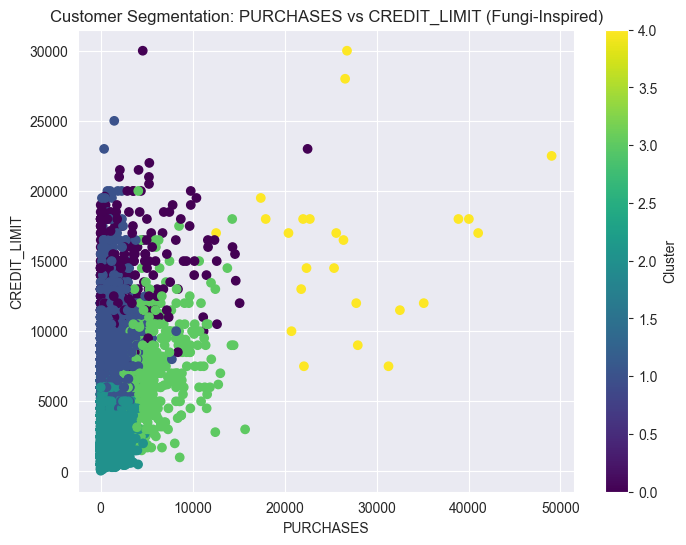

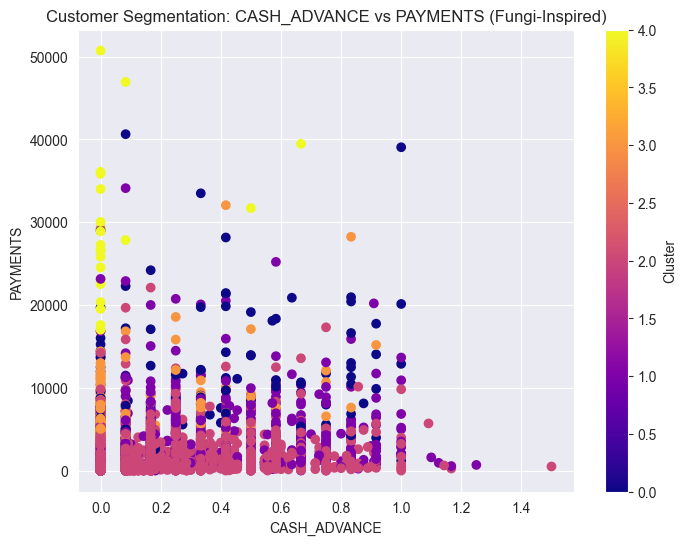

In [63]:
# Aplicar nuestro algoritmo FungiInspiredClustering
n_clusters = 5
fungi_clustering = FungiInspiredClustering(manhattan_distance,n_clusters=n_clusters, max_iter=100, local_radius=0.5, global_radius=2.0)
fungi_clustering.fit(df.to_numpy())

# Asignar las etiquetas de clúster al dataframe
df['Cluster'] = fungi_clustering.labels

# Métricas de rendimiento
silhouette_avg = silhouette_score(df.to_numpy(), df['Cluster'])
print(f"Coeficiente de Silhouette: {silhouette_avg}")

# Imprimir datos de centroides y asignaciones
print(f"\nCentroides finales:\n{fungi_clustering.centroids}\n")

# Tamaño de cada clúster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Tamaño de cada clúster:\n{cluster_sizes}\n")

# Visualización: Graficar PURCHASES vs CREDIT_LIMIT con los clústeres
plt.figure(figsize=(8,6))
plt.scatter(df['PURCHASES'], df['CREDIT_LIMIT'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title("Customer Segmentation: PURCHASES vs CREDIT_LIMIT (Fungi-Inspired)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT_LIMIT")
plt.colorbar(label="Cluster")
plt.show()

# Visualización: CASH_ADVANCE vs PAYMENTS
plt.figure(figsize=(8,6))
plt.scatter(df['CASH_ADVANCE_FREQUENCY'], df['PAYMENTS'], c=df['Cluster'], cmap='plasma', marker='o')
plt.title("Customer Segmentation: CASH_ADVANCE vs PAYMENTS (Fungi-Inspired)")
plt.xlabel("CASH_ADVANCE")
plt.ylabel("PAYMENTS")
plt.colorbar(label="Cluster")
plt.show()

Coeficiente de Silhouette: 0.3983552683224506

Centroides finales:
[[ 5.06112426e+03  1.46361585e+03  9.03194553e+02  5.60214767e+02
   1.31529802e+00 -1.05908016e+00  1.89388857e+01  1.19618547e+04
   2.34778802e+03  3.27795114e-01  2.79258208e-01]
 [ 1.74373363e+03  1.10823096e+03  6.57591527e+02  4.52821062e+02
   4.20755865e-01 -1.21005702e+00  1.91180529e+01  6.24005608e+03
   1.74068555e+03  1.42336362e-01  2.16404901e+00]
 [ 7.79451520e+02  4.78189531e+02  2.24228103e+02  2.53111426e+02
  -1.22025591e+00  1.35991967e+00  7.56228379e+00  2.06038958e+03
   8.43193965e+02  7.56335404e-01  1.76320627e+00]
 [ 3.31037036e+03  4.44473572e+03  2.90911367e+03  1.53811884e+03
   9.25956863e-01  1.79431387e-01  4.88513508e+01  8.79551047e+03
   9.87813549e+03 -5.27420975e-01 -1.90879044e-01]
 [ 5.72733452e+03  2.52626457e+04  2.01978005e+04  5.06382066e+03
   1.34149067e+00  1.20510234e+00  1.17492706e+02  1.62910184e+04
   2.88431897e+04  9.80937218e-01  4.92383362e+00]]

Tamaño de cada c

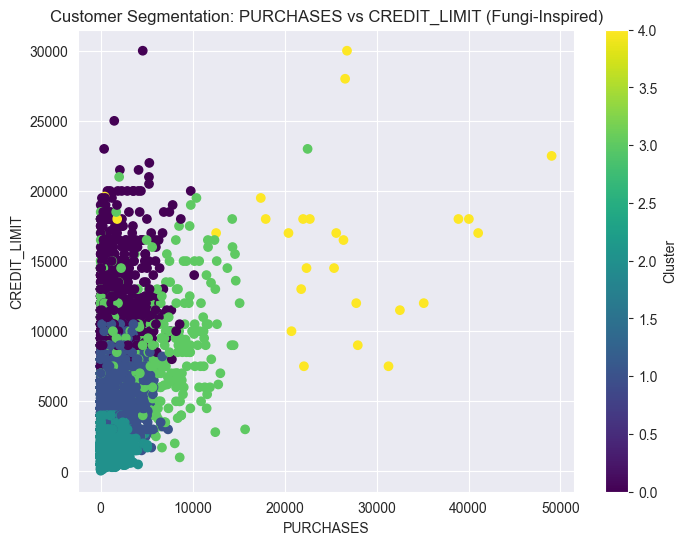

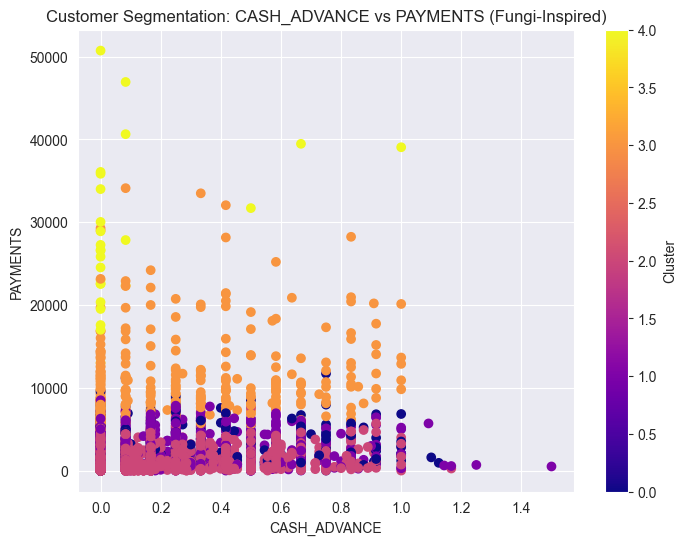

In [64]:
n_clusters = 5
fungi_clustering = FungiInspiredClustering(minkowski_distance,n_clusters=n_clusters, max_iter=100, local_radius=0.5, global_radius=2.0)
fungi_clustering.fit(df.to_numpy())

# Asignar las etiquetas de clúster al dataframe
df['Cluster'] = fungi_clustering.labels

# Métricas de rendimiento
silhouette_avg = silhouette_score(df.to_numpy(), df['Cluster'])
print(f"Coeficiente de Silhouette: {silhouette_avg}")

# Imprimir datos de centroides y asignaciones
print(f"\nCentroides finales:\n{fungi_clustering.centroids}\n")

# Tamaño de cada clúster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Tamaño de cada clúster:\n{cluster_sizes}\n")

# Visualización: Graficar PURCHASES vs CREDIT_LIMIT con los clústeres
plt.figure(figsize=(8,6))
plt.scatter(df['PURCHASES'], df['CREDIT_LIMIT'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title("Customer Segmentation: PURCHASES vs CREDIT_LIMIT (Fungi-Inspired)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT_LIMIT")
plt.colorbar(label="Cluster")
plt.show()

# Visualización: CASH_ADVANCE vs PAYMENTS
plt.figure(figsize=(8,6))
plt.scatter(df['CASH_ADVANCE_FREQUENCY'], df['PAYMENTS'], c=df['Cluster'], cmap='plasma', marker='o')
plt.title("Customer Segmentation: CASH_ADVANCE vs PAYMENTS (Fungi-Inspired)")
plt.xlabel("CASH_ADVANCE")
plt.ylabel("PAYMENTS")
plt.colorbar(label="Cluster")
plt.show()

Podemos ver que el mejor resultado dado por el modelo se dio cuando usamos todas las características estandarizadas y la distancia de manhattan por lo que se usara esta combinación para medir el rendimiento del modelo